<div style="background-color: #f8f9fa; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">
  <div style="display: flex; justify-content: space-between; align-items: center;">
    <img src="https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/_assets/logo_sigmoidal.png" alt="Sigmoidal" style="height: 60px;">
    <div style="text-align: right;">
      <p style="margin: 0; font-size: 14px; color: #6c757d;"><strong>Carlos Melo</strong> · Sigmoidal</p>
      <p style="margin: 0; font-size: 12px; color: #6c757d;">Cientista de Dados · Visão Computacional</p>
    </div>
  </div>
</div>

# Pipelines no Scikit-Learn: transformações sem data leakage

Material de apoio do artigo [Pipelines no Scikit-Learn](https://sigmoidal.ai) no blog da Sigmoidal.

Aqui você vai aprender a transformar dados do jeito certo: ajustando as transformações **apenas no conjunto de treino**, entendendo o que é *data leakage* e montando um `Pipeline` completo que junta pré-processamento e modelo em um único objeto.

> O notebook roda de ponta a ponta no Google Colab gratuito, sem GPU.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

RANDOM_STATE = 42

## 1. Os dados

Vamos usar o clássico dataset do Titanic, que tem tudo o que um dataset do mundo real costuma ter: variáveis numéricas, variáveis categóricas e valores ausentes.

In [2]:
df = sns.load_dataset("titanic")

colunas = ["survived", "pclass", "sex", "age", "fare", "embarked"]
df = df[colunas]
df.head()

,survived,pclass,sex,age,fare,embarked
0,0,3,male,22.0,7.2500,S
1,1,1,female,38.0,71.2833,C
2,1,3,female,26.0,7.9250,S
3,1,1,female,35.0,53.1000,S
4,0,3,male,35.0,8.0500,S


In [3]:
df.isna().sum()

survived      0
pclass        0
sex           0
age         177
fare          0
embarked      2
dtype: int64

## 2. Separar treino e teste ANTES de qualquer transformação

O conjunto de teste simula dados que o modelo nunca viu. Se qualquer estatística dele (média, desvio padrão, categorias) influenciar o pré-processamento, a avaliação fica contaminada.

In [4]:
X = df.drop(columns="survived")
y = df["survived"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Treino: {X_treino.shape[0]} passageiros")
print(f"Teste:  {X_teste.shape[0]} passageiros")

Treino: 712 passageiros
Teste:  179 passageiros


## 3. Como funciona um transformador: `fit` aprende, `transform` aplica

O `StandardScaler` padroniza cada coluna. O método `fit` **aprende** a média e o desvio padrão; o `transform` **aplica** a fórmula usando o que foi aprendido. Por isso o `fit` acontece só no treino.

In [5]:
scaler = StandardScaler()

colunas_numericas = ["age", "fare"]
scaler.fit(X_treino[colunas_numericas].dropna())

print("Médias aprendidas no treino:")
for coluna, media, desvio in zip(colunas_numericas, scaler.mean_, scaler.scale_):
    print(f"  {coluna}: média = {media:.2f}, desvio padrão = {desvio:.2f}")

Médias aprendidas no treino:
  age: média = 29.81, desvio padrão = 14.47
  fare: média = 33.86, desvio padrão = 50.49


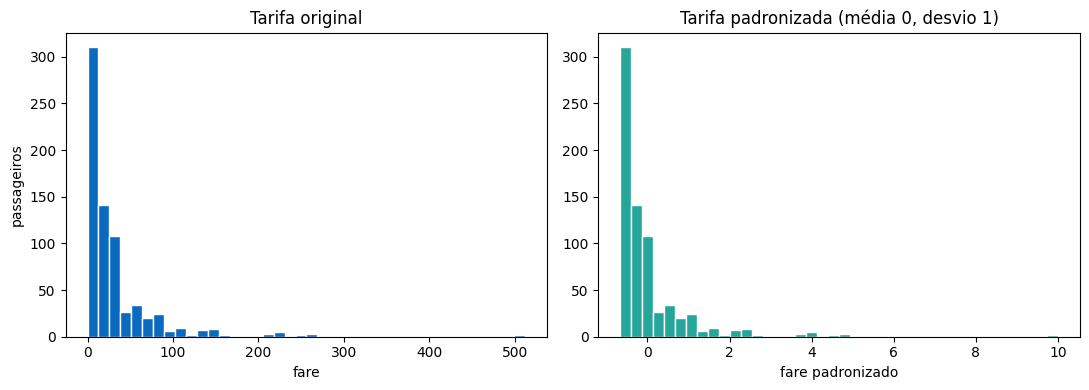

In [6]:
fare_treino = X_treino[["fare"]].dropna()
fare_padronizado = StandardScaler().fit_transform(fare_treino)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.hist(fare_treino["fare"], bins=40, color="#0A6ABF", edgecolor="white")
ax1.set_title("Tarifa original")
ax1.set_xlabel("fare")
ax1.set_ylabel("passageiros")

ax2.hist(fare_padronizado, bins=40, color="#26A69A", edgecolor="white")
ax2.set_title("Tarifa padronizada (média 0, desvio 1)")
ax2.set_xlabel("fare padronizado")

plt.tight_layout()
plt.show()

## 4. O erro clássico: data leakage

*Data leakage* acontece quando informação do teste vaza para o treinamento. O exemplo mais comum: ajustar o `scaler` no dataset inteiro antes de dividir. A diferença parece pequena, mas o teste deixa de ser uma simulação honesta de dados novos.

In [7]:
scaler_certo = StandardScaler().fit(X_treino[["fare"]].dropna())
scaler_vazado = StandardScaler().fit(X[["fare"]].dropna())

print(f"Média aprendida SÓ com o treino (certo):        {scaler_certo.mean_[0]:.4f}")
print(f"Média aprendida com treino + teste (vazamento): {scaler_vazado.mean_[0]:.4f}")
print()
print("O segundo scaler 'conhece' estatísticas do teste antes da avaliação.")

Média aprendida SÓ com o treino (certo):        31.8198
Média aprendida com treino + teste (vazamento): 32.2042

O segundo scaler 'conhece' estatísticas do teste antes da avaliação.


## 5. `ColumnTransformer`: cada tipo de coluna com seu tratamento

Colunas numéricas recebem imputação pela mediana e padronização. Colunas categóricas recebem imputação pela moda e *one-hot encoding*.

In [8]:
colunas_numericas = ["age", "fare"]
colunas_categoricas = ["pclass", "sex", "embarked"]

transformador_numerico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="median")),
    ("padronizador", StandardScaler()),
])

transformador_categorico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("codificador", OneHotEncoder(handle_unknown="ignore")),
])

pre_processador = ColumnTransformer(transformers=[
    ("numerico", transformador_numerico, colunas_numericas),
    ("categorico", transformador_categorico, colunas_categoricas),
])

pre_processador

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerico', ...), ('categorico', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_na

## 6. O `Pipeline` completo: pré-processamento + modelo em um único objeto

Com o pipeline, o `fit` ajusta as transformações e o modelo usando apenas o treino, e o `predict` aplica tudo na ordem certa. O risco de vazamento desaparece por construção.

In [9]:
modelo = Pipeline(steps=[
    ("pre_processamento", pre_processador),
    ("classificador", LogisticRegression(max_iter=1000)),
])

modelo.fit(X_treino, y_treino)

acuracia_treino = modelo.score(X_treino, y_treino)
acuracia_teste = modelo.score(X_teste, y_teste)

print(f"Acurácia no treino: {acuracia_treino:.3f}")
print(f"Acurácia no teste:  {acuracia_teste:.3f}")

Acurácia no treino: 0.801
Acurácia no teste:  0.771


## 7. Validação cruzada sem vazamento

Como o pipeline encapsula o pré-processamento, o `cross_val_score` refaz o `fit` das transformações dentro de cada *fold*, usando só os dados de treino daquele fold. É a validação cruzada do jeito certo.

In [10]:
scores = cross_val_score(modelo, X_treino, y_treino, cv=5, scoring="accuracy")

print(f"Acurácia por fold: {np.round(scores, 3)}")
print(f"Média: {scores.mean():.3f} ± {scores.std():.3f}")

Acurácia por fold: [0.79  0.762 0.796 0.831 0.81 ]
Média: 0.798 ± 0.023


---

Este notebook acompanha o artigo completo no blog: [sigmoidal.ai](https://sigmoidal.ai)